1. Напишите программу Python для применения фильтра среднего к изображению с шумом типа «соль-перец». Опишите вывод, включая способность фильтра среднего удалять шум. Без OpenCV.

2. Опишите, насколько эффективен фильтр среднего для удаления шума типа «соль-перец». Основываясь на вашем понимании медианного фильтра, можете ли вы объяснить, почему фильтр среднего не может удалить шум типа «соль-перец»? Измените программу из задания 1 для медианного фильтра.

3. Напишите программу и проверьте, ли использовать фильтр максимального значения или минимальный фильтр для удаления шума типа «соль-перец»?

4. Напишите программу Python для получения разности лапласиана гауссовой функции (LoG). Возьмите изображение 01.jpg из https://drive.google.com/drive/folders/1syZR4mVjJ9Unypdqx8mIXeHew58k83pA?usp=sharing

Псевдокод программы будет следующим:

* Прочитайте изображение.

* Применить фильтр LoG, предполагая стандартное отклонение 0,1, и сохранить изображение как im1.

* Применить фильтр LoG, предполагая стандартное отклонение 0,2, и сохранить изображение как im2.

* Найти разницу между двумя изображениями и сохранить полученное изображение?

## 4. Напишите программу Python для получения разности лапласиана гауссовой функции (LoG). Возьмите изображение 01.jpg.

Псевдокод программы будет следующим:

* Прочитайте изображение.

* Применить фильтр LoG, предполагая стандартное отклонение 0,1, и сохранить изображение как im1.

* Применить фильтр LoG, предполагая стандартное отклонение 0,2, и сохранить изображение как im2.

* Найти разницу между двумя изображениями и сохранить полученное изображение?

In [9]:
import cv2
import numpy as np

def generate_log_kernel(sigma):
    """Генерирует ядро лапласиана гауссовой функции (LoG) для заданного sigma."""
    kernel_radius = int(np.ceil(3 * sigma))
    kernel_size = 2 * kernel_radius + 1

    x = np.arange(-kernel_radius, kernel_radius + 1, dtype=np.float32)
    y = np.arange(-kernel_radius, kernel_radius + 1, dtype=np.float32)
    X, Y = np.meshgrid(x, y)

    exponent = -(X**2 + Y**2) / (2 * sigma**2)
    log_kernel = -(1 / (np.pi * sigma**4)) * (1 - (X**2 + Y**2)/(2 * sigma**2)) * np.exp(exponent)

    return log_kernel

def apply_log_filter(image, sigma):
    """Применяет фильтр LoG к изображению."""
    kernel = generate_log_kernel(sigma)

    image_float = image.astype(np.float32)
    filtered_image = cv2.filter2D(image_float, -1, kernel)

    return filtered_image

In [10]:
image = cv2.imread('01.jpg', cv2.IMREAD_GRAYSCALE)

sigma1 = 1
im1 = apply_log_filter(image, sigma1)

sigma2 = 2
im2 = apply_log_filter(image, sigma2)

difference = im2 - im1

def normalize_image(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

im1_normalized = normalize_image(im1)
im2_normalized = normalize_image(im2)
difference_normalized = normalize_image(difference)


cv2.imwrite('im1_sigma1.jpg', im1_normalized)
cv2.imwrite('im2_sigma2.jpg', im2_normalized)
cv2.imwrite('difference.jpg', difference_normalized)

print("успешно")

успешно


## 1. Напишите программу Python для применения фильтра среднего к изображению с шумом типа «соль-перец». Опишите вывод, включая способность фильтра среднего удалять шум. Без OpenCV.

In [11]:
from PIL import Image

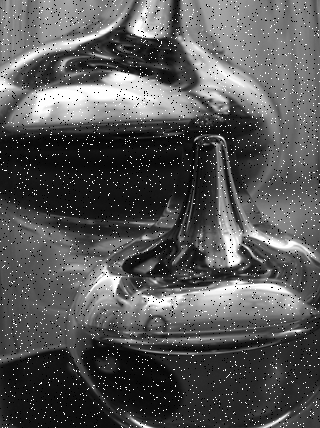

In [22]:
image = Image.open('Noise_salt_and_pepper.png').convert('L')
image_array = np.array(image)
display(image)

In [21]:
height, width = image_array.shape
height, width

(428, 320)

In [23]:
filtered_image_array = np.zeros_like(image_array)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)

In [24]:
# Применение фильтра среднего
for i in range(1, height - 1):
    for j in range(1, width - 1):
        window = image_array[i-1:i+2, j-1:j+2]
        filtered_image_array[i, j] = np.sum(window * kernel)

filtered_image = Image.fromarray(filtered_image_array)

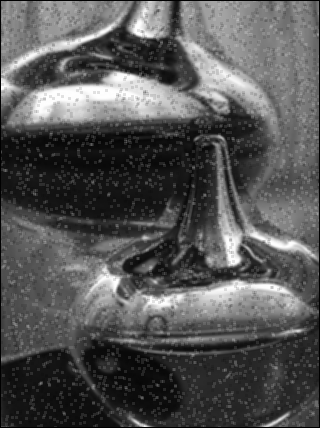

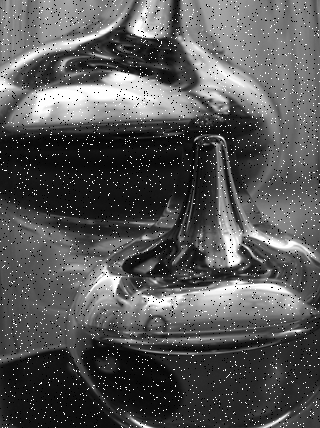

In [28]:
filtered_image.save('mean_filtered_image.png')
display(filtered_image); display(image)

## 2. Опишите, насколько эффективен фильтр среднего для удаления шума типа «соль-перец». Основываясь на вашем понимании медианного фильтра, можете ли вы объяснить, почему фильтр среднего не может удалить шум типа «соль-перец»? Измените программу из задания 1 для медианного фильтра.